In [15]:
from glob import glob
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.ticker as plticker
import matplotlib.dates as mdates

# Grab a several npz test files
### This assumes the test files are generated from scripts/icetray/step1/monitoring_extractors/pass3_charge_fadc_gain.py

In [36]:
runs, starts, percent_diffs = [], [], []

for f in glob("./*fadc_atwd_charge.npz"):
    x = np.load(f)
    run = int(f.split("_")[1][:6])
    runs.append(run)
    starts.append(x['start'])

    atwd, fadc = x['atwd_peak'], x['fadc_peak']
    print(atwd.shape, fadc.shape)
    percent_diffs.append(100 * (atwd-fadc) / 0.5 / (atwd+fadc))
    print(percent_diffs[-1].shape)

runs = np.array(runs)
starts = np.array(starts)
percent_diffs = np.array(percent_diffs)

(87, 61) (87, 61)
(87, 61)
(87, 61) (87, 61)
(87, 61)
(87, 61) (87, 61)
(87, 61)
(3, 87, 61)


### Plot the ATWD/FADC difference as a function of time

Text(0, 0.5, 'ATWD-FADC (%)')

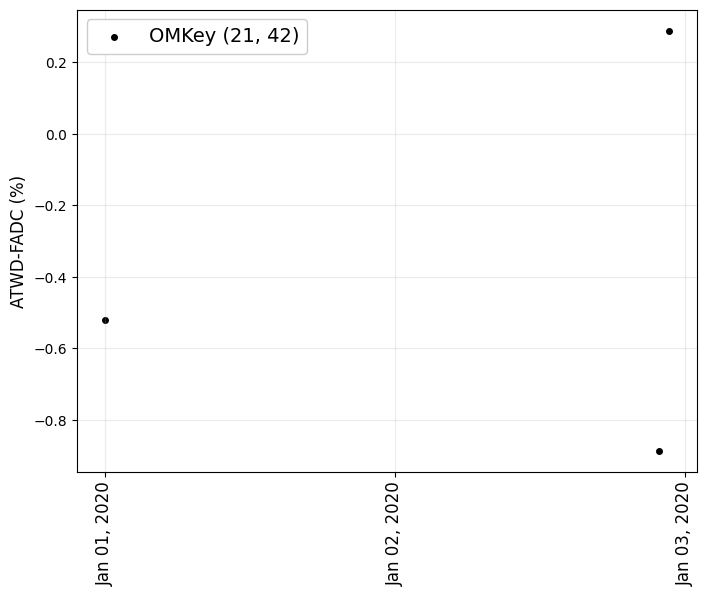

In [52]:
omkey = (21, 42)

fig, ax = plt.subplots(figsize=(8,6))
loc = plticker.MultipleLocator(base=1) # 1 Day labels

ax.scatter(starts,
           percent_diffs[:,*omkey],
           label = f"OMKey {str(omkey)}",
           s=16,
           c='k',)

ax.legend(framealpha=1, fontsize=14)
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %Y'))
ax.tick_params(axis='x', labelsize=12, labelrotation=90)
ax.tick_params(axis='y', labelsize=10)
ax.set_ylabel("ATWD-FADC (%)", fontsize=12)

### Plot the ATWD/FADC difference as a function of run number

Text(0, 0.5, 'ATWD-FADC (%)')

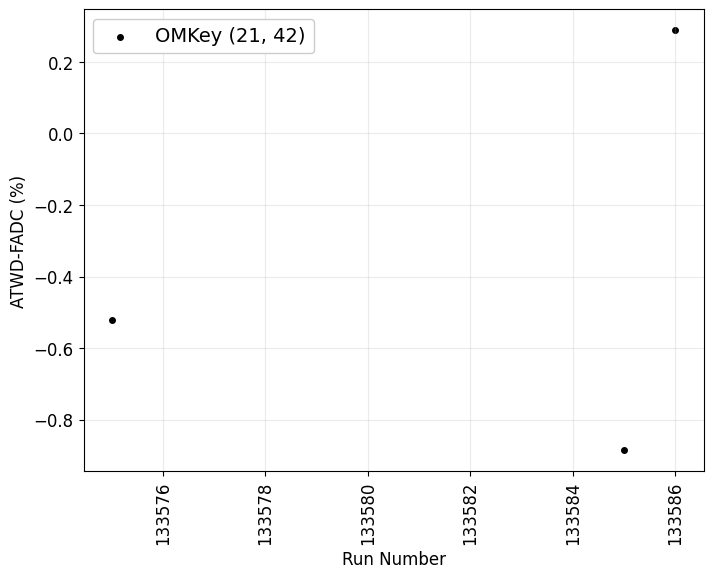

In [53]:
omkey = (21, 42)

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(runs,
           percent_diffs[:,*omkey],
           label = f"OMKey {str(omkey)}",
           s=16,
           c='k',)

ax.legend(framealpha=1, fontsize=14)
ax.grid(alpha=0.25)
ax.tick_params(labelsize=12)
ax.tick_params(axis='x', labelrotation=90)
ax.ticklabel_format(useOffset=False)
ax.set_xlabel("Run Number", fontsize=12)
ax.set_ylabel("ATWD-FADC (%)", fontsize=12)